#### Vendor TimeView Model on Simulated Tumour Data

This implementation runs on data:
- with no unobserved heteroegeneity in the DGP,
- with no observational noise, 
- with equally spaced observations for all individuals. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import pytorch_lightning as pl
import optuna

from pathlib import Path
import sys

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

# Functions needed to run the timeview model
from scripts.shape_uncertainty.analysis.timeview_helpers import run_timeview_optuna_trial
from scripts.shape_uncertainty.analysis.timeview_helpers import best_timeview_hyperparams
from scripts.shape_uncertainty.analysis.timeview_helpers import train_final_timeview_model
from scripts.shape_uncertainty.analysis.timeview_helpers import save_timeview_run
from scripts.shape_uncertainty.analysis.timeview_helpers import load_timeview_run 
from scripts.shape_uncertainty.analysis.timeview_helpers import TimeViewInferenceEngine

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_evaluation import ExtractionEvaluator
from scripts.shape_uncertainty.model.model_evaluation import  ModelEvaluator

# Functions needed for data generation and plotting
from scripts.shape_uncertainty.simulated_data.data_generator import make_data_splits
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary
from scripts.shape_uncertainty.analysis.plot_helpers import plot_individual_diagnostic

# Supressing error messages
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", ".*does not have many workers.*")

In [2]:
# Model configuration
NR_INTERIOR_KNOTS = 5 # B = 9 matches TIMEVIEW 
T = 1.0

# Dataset configuration
NR_OBS = 20
SIGMA = 0.0 # no observation noise
ALPHA_G, ALPHA_D = 0.0, 0.0 # no unobserved heterogeneity

#### Generate a SimulatedDataset dataset (train, val, test)

In [3]:
# Generate a simulated dataset
simulation_config = dict(D=2000, 
                         N=NR_OBS, 
                         hyperparams={"g0": 2.0, "d0": 180.0, "rho0": 10.0, "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}, 
                         sigma=SIGMA, # Variance for the observation noise
                         ranges=None, # covariate ranges
                         T=T, 
                         regular=True, # equally spaced observations
                         include_endpoints=True, # ignored when regular=True
)

train, val, test = make_data_splits(simulation_config, seed=42)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 2000 2000 - sigma: 0.0


#### Train a TimeView on the tumour dataset

In [4]:
# Define the basis dimension for the model based on NR_INTERIOR_KNOTS
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)
NR_BASIS = knot_objects["nr_basis"]

In [5]:
# Run Optuna search on a specified search space and retrain the best config
SEARCH_SPACE = {
    "hidden_sizes": {"nr_layers": 3, "low": 16, "high": 128},
    "activation": ["relu", "sigmoid", "tanh", "leaky_relu", "elu", "selu"],
    "dropout": {"low": 0.0, "high": 0.5},
    "lr": {"low": 1e-4, "high": 1e-1, "log": True},
    "batch_size": [64, 128],
    "weight_decay": {"low": 1e-6, "high": 1e-1, "log": True},
}

study = optuna.create_study(direction="minimize")
study.optimize(
    lambda trial: run_timeview_optuna_trial(
                trial, 
                train, 
                val, 
                nr_basis=NR_BASIS, 
                search_space=SEARCH_SPACE,
                epochs=200, 
                patience=10,
    ),
    n_trials=100,
)

# Extract best config and retrain:
best_params = best_timeview_hyperparams(study, SEARCH_SPACE)
tuned = train_final_timeview_model(
    best_params, 
    train, 
    val, 
    nr_basis=NR_BASIS, 
    epochs=200, 
    patience=10,
)
print("best val objective:", round(tuned["best_value"], 3))
print("best params:", best_params)

# Save the trained model
save_timeview_run(tuned, generate_config=simulation_config, path="timeview_baseline")

[I 2026-07-16 13:32:55,162] A new study created in memory with name: no-name-c1f6855b-deb1-4dfd-8ce2-89d67c173977
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/Users/richardfranck/venvs/thesis/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we fou

best val objective: 0.003
best params: {'hidden_sizes': [115, 125, 60], 'activation': 'leaky_relu', 'dropout': 0.0668555924905076, 'lr': 0.002307325021591451, 'batch_size': 128, 'weight_decay': 6.605422334841698e-05}


#### Load a saved TimeView model for inspection

In [6]:
# Load a trained TimeView model
run = load_timeview_run(path="timeview_baseline")

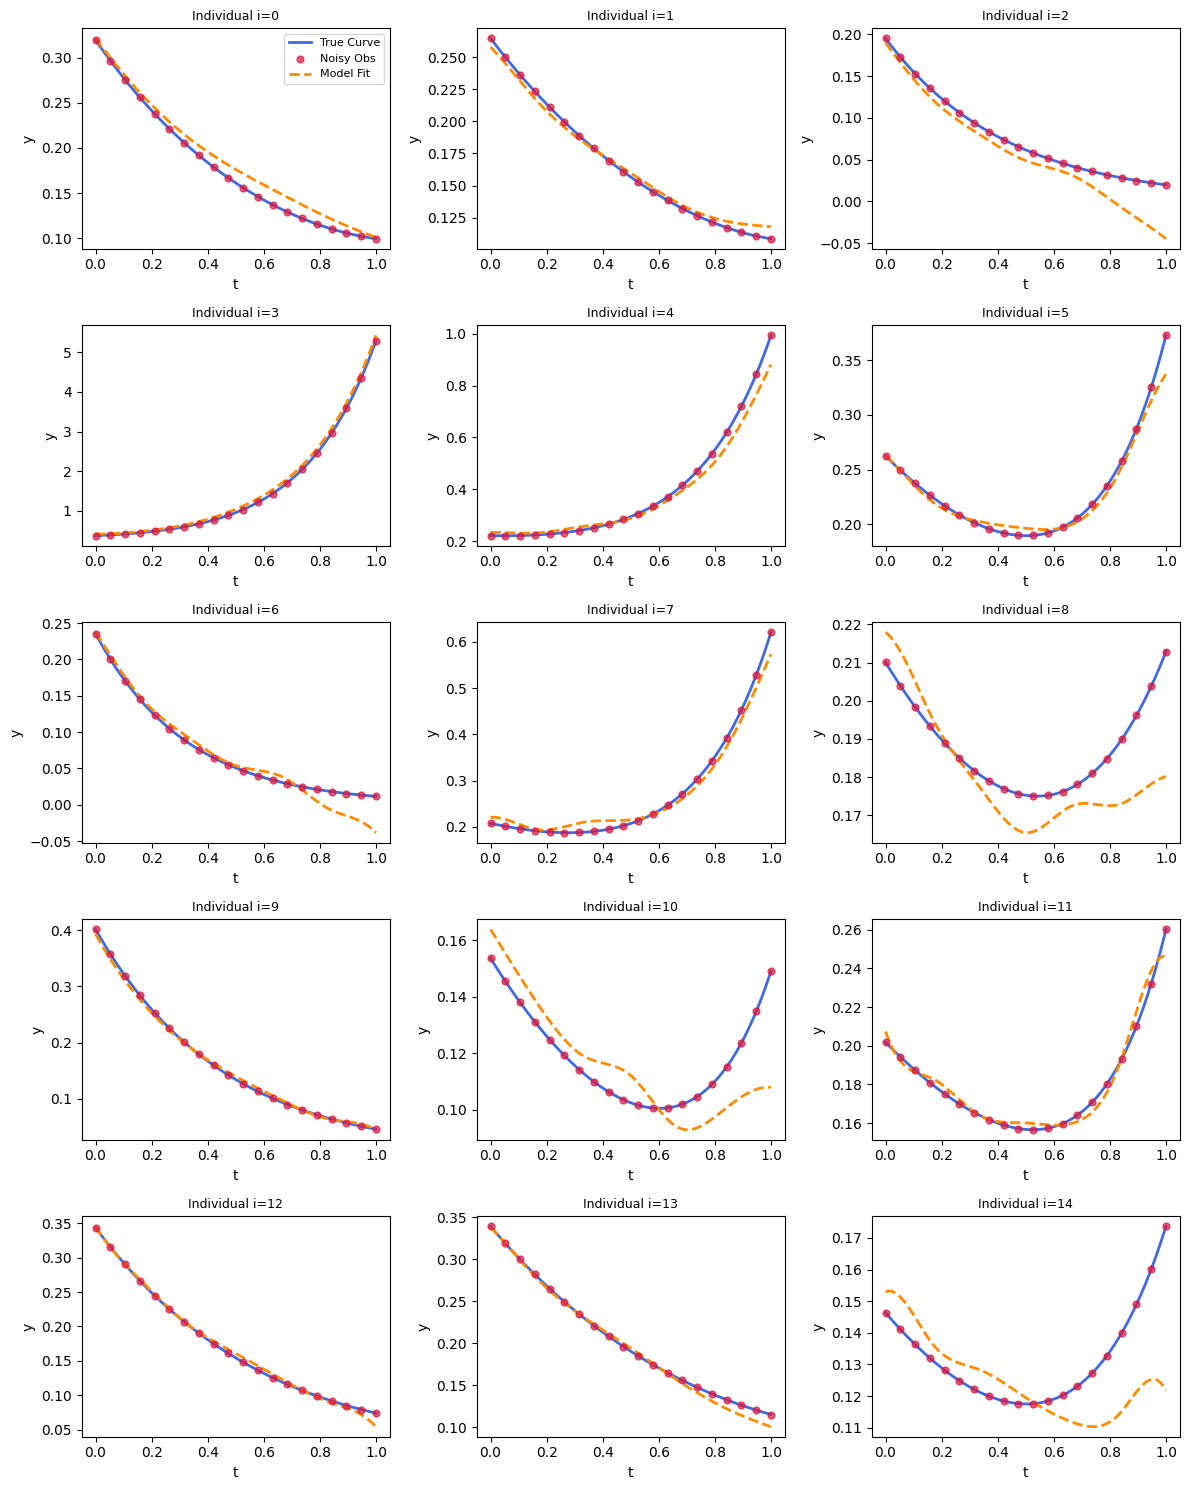

In [7]:
# Plot observations
target_patients = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

plotting_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        normaliser=run["normaliser"],
)

fig = plot_individual_diagnostic(
    dataset=test,
    indices=target_patients,
    inference_engine=plotting_engine,
    show_true=True,        # 1. Ground truth
    show_noisy=True,       # 2. Noisy observations
    show_estimated=True,   # 3. Trained model
)
plt.show()

In [8]:
# Compute value-space accuracy on the test set
evaluator = ModelEvaluator(inference_engine=plotting_engine, test_dataset=test)
evaluation_times = np.linspace(0.0, test.T, 200)
value_metrics = evaluator.compute_value_space_accuracy(evaluation_times)
print(f"Value-space RMSE: {value_metrics['rmse']:.4f}")
print(f"Value-space R^2:  {value_metrics['r2']:.4f}")

Value-space RMSE: 0.0274
Value-space R^2:  0.9965


#### Predict shape summaries with the naiive shape extration algorithm

In [9]:
# Timeview shape extraction
ZETA_REL = 0.00
UPSILON_1_REL, UPSILON_2_REL = 0.00, 0.00
UPSILON_PRUNE_REL, DO_PRUNE = 0.00, False

# Initialise an inference engine for analysis
timeview_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        zeta_rel=ZETA_REL,
        upsilon_rel_1=UPSILON_1_REL,
        upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=UPSILON_PRUNE_REL,
        do_prune=DO_PRUNE,
        normaliser=run["normaliser"],
)

In [10]:
# Step 1: Create a model evaluator for the test dataset
evaluator = ModelEvaluator(timeview_engine, test)

# Step 2: Get the analytically-derived ground-truth from the data generating process
extraction_eval = ExtractionEvaluator(test)
true_summaries = extraction_eval.get_true_shape_summary(UPSILON_1_REL, UPSILON_2_REL)

# Step 3: Get the shape summaries for the timeview model
predicted_summaries = evaluator.get_shape_summary_estimates()

# Step 4: Print table of shape summaries
def _shape_states(summary):
    return [state for state, _ in summary]

df_shapes = pd.DataFrame({
    "patient": target_patients,
    "true_summary": [_shape_states(true_summaries[i]) for i in target_patients],
    "predicted_summary": [_shape_states(predicted_summaries[i]) for i in target_patients],
})
display(df_shapes)

# Step 5: Print table of transition time points
def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

df_transition_times = pd.DataFrame({
    "patient": target_patients,
    "true_transition_times": [_transition_times(true_summaries[i]) for i in target_patients],
    "predicted_transition_times": [_transition_times(predicted_summaries[i]) for i in target_patients],
})
display(df_transition_times)

# Compute shape extraction accuracy on the test set
accuracy = extraction_eval.exact_sequence_match(predicted_summaries, true_summaries)
print(f"Exact state-sequence match accuracy: {accuracy:.1%}")


,patient,true_summary,predicted_summary
0,0,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex..."
1,1,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav..."
2,2,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex..."
3,3,[convex_increasing],"[convex_decreasing, convex_increasing]"
4,4,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
5,5,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex..."
6,6,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav..."
7,7,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve..."
8,8,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, concav..."
9,9,[convex_decreasing],"[convex_decreasing, concave_decreasing]"


,patient,true_transition_times,predicted_transition_times
0,0,[0.0000],"[0.0000, 0.6576, 0.6766]"
1,1,[0.0000],"[0.0000, 0.0931, 0.4443, 0.5455, 0.9896]"
2,2,[0.0000],"[0.0000, 0.3265, 0.3415, 0.5740, 0.7978, 0.8927]"
3,3,[0.0000],"[0.0000, 0.0162]"
4,4,"[0.0000, 0.0479]","[0.0000, 0.0098, 0.0696, 0.1294, 0.2756, 0.3750]"
5,5,"[0.0000, 0.5015]","[0.0000, 0.0645, 0.5686, 0.8985]"
6,6,[0.0000],"[0.0000, 0.0181, 0.3188, 0.3498, 0.5702, 0.752..."
7,7,"[0.0000, 0.2790]","[0.0000, 0.0078, 0.0958, 0.1879, 0.2783, 0.4244]"
8,8,"[0.0000, 0.5419]","[0.0000, 0.1180, 0.2969, 0.3568, 0.5043, 0.599..."
9,9,[0.0000],"[0.0000, 0.8850]"


Exact state-sequence match accuracy: 5.3%


#### Predict shape summaries with the shape extration algorithm with pruning

In [13]:
# Shape extraction with pruning
ZETA_REL = 0.000001
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
UPSILON_PRUNE_REL, DO_PRUNE = 0.06, True

# Initialise an inference engine for analysis
pruning_engine = TimeViewInferenceEngine(
        run["model"], 
        feature_names=list(train.X.keys()),
        C=knot_objects["C"],
        breakpoints=knot_objects["breakpoints"],
        zeta_rel=ZETA_REL,
        upsilon_rel_1=UPSILON_1_REL,
        upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=UPSILON_PRUNE_REL,
        do_prune=DO_PRUNE,
        normaliser=run["normaliser"],
)

In [14]:
# Step 1: Create a model evaluator for the test dataset and get the shape summaries 
evaluator = ModelEvaluator(pruning_engine, test)
predicted_summaries = evaluator.get_shape_summary_estimates()

# Step 2: Get the analytically-derived ground-truth from the data generating process
extraction_eval = ExtractionEvaluator(test)
true_summaries = extraction_eval.get_true_shape_summary(UPSILON_1_REL, UPSILON_2_REL)

# Step 3: Print table of shape summaries
def _shape_states(summary):
    return [state for state, _ in summary]

df_shapes = pd.DataFrame({
    "patient": target_patients,
    "true_summary": [_shape_states(true_summaries[i]) for i in target_patients],
    "predicted_summary": [_shape_states(predicted_summaries[i]) for i in target_patients],
})
display(df_shapes)

# Step 4: Print table of transition time points
def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

df_transition_times = pd.DataFrame({
    "patient": target_patients,
    "true_transition_times": [_transition_times(true_summaries[i]) for i in target_patients],
    "predicted_transition_times": [_transition_times(predicted_summaries[i]) for i in target_patients],
})
display(df_transition_times)


# Compute shape extraction accuracy on the test set
accuracy = extraction_eval.exact_sequence_match(predicted_summaries, true_summaries)
print(f"Exact state-sequence match accuracy: {accuracy:.1%}")

,patient,true_summary,predicted_summary
0,0,[convex_decreasing],[convex_decreasing]
1,1,[convex_decreasing],[convex_decreasing]
2,2,[convex_decreasing],[convex_decreasing]
3,3,[convex_increasing],[convex_increasing]
4,4,"[convex_decreasing, convex_increasing]",[convex_increasing]
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
6,6,[convex_decreasing],[convex_decreasing]
7,7,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
8,8,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
9,9,[convex_decreasing],[convex_decreasing]


,patient,true_transition_times,predicted_transition_times
0,0,[0.0000],[0.0000]
1,1,[0.0000],[0.0000]
2,2,[0.0000],[0.0000]
3,3,[0.0000],[0.0000]
4,4,"[0.0000, 0.0479]",[0.0000]
5,5,"[0.0000, 0.5015]","[0.0000, 0.5686]"
6,6,[0.0000],[0.0000]
7,7,"[0.0000, 0.2790]","[0.0000, 0.1879]"
8,8,"[0.0000, 0.5419]","[0.0000, 0.5043]"
9,9,[0.0000],[0.0000]


Exact state-sequence match accuracy: 72.9%
